In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read the data
df = pd.read_csv('/content/retail_store_inventory.csv')
df.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
# inspect data
# missing entries
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [4]:
# describe the data
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


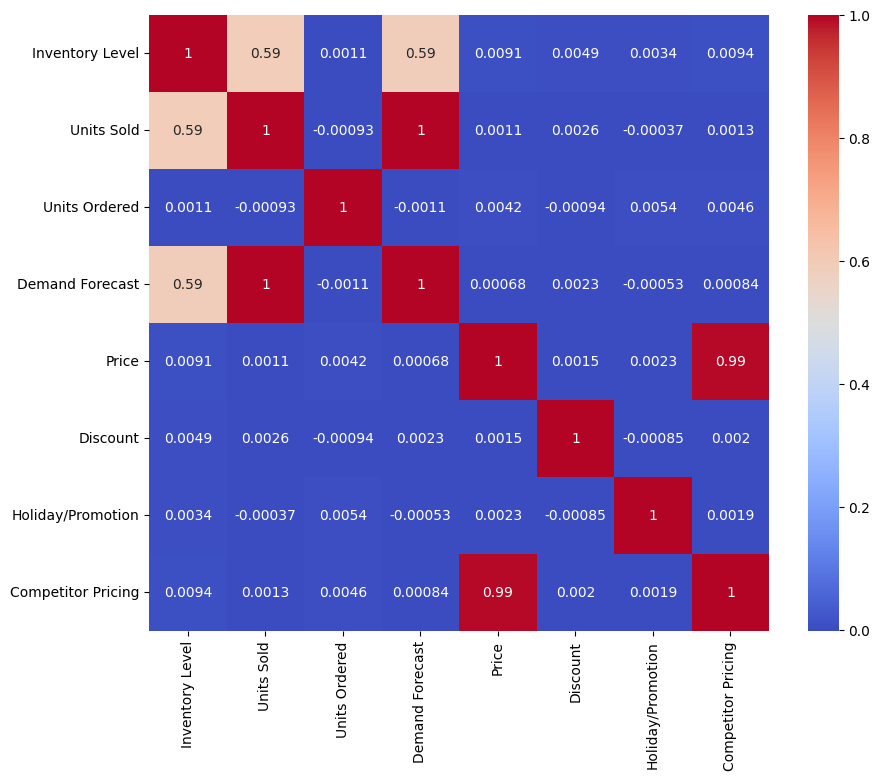

In [5]:
# build a heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [6]:
# drop the demand forecast due to the strong correlation
df = df.drop('Demand Forecast', axis=1)

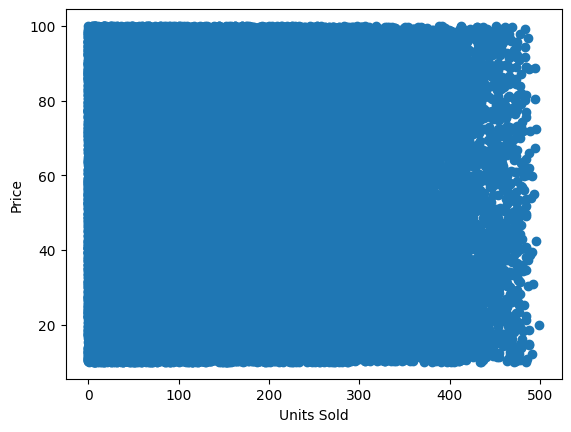

In [7]:
# investigate non linear relationships
# units sold vs price
plt.scatter(df['Units Sold'], df['Price'])
plt.xlabel('Units Sold')
plt.ylabel('Price')
plt.show()

In [8]:
# discount vs units sold
df.groupby("Discount")["Units Sold"].mean()

,Units Sold
Discount,
0,135.694585
5,136.567405
10,136.769851
15,136.655293
20,136.640775


In [9]:
# promotion vs units sold
df.groupby("Holiday/Promotion")["Units Sold"].mean()

,Units Sold
Holiday/Promotion,
0,136.505375
1,136.423926


In [10]:
# change the data to make it more realistic
# create a copt of the original dataset
original_df = df.copy()

In [11]:
# change units sold
np.random.seed(42)

df["Units Sold"] = (
    200
    - 1.2 * df["Price"]                 # price effect
    + 2.5 * df["Discount"]              # discount effect
    + 25 * df["Holiday/Promotion"]      # promotion boost
    + 0.25 * df["Inventory Level"]       # stock availability
    + np.random.normal(0, 10, len(df))  # noise
)

In [12]:
# to ensure there is no negative sales to make it more realistic
df["Units Sold"] = df["Units Sold"].clip(lower=0)

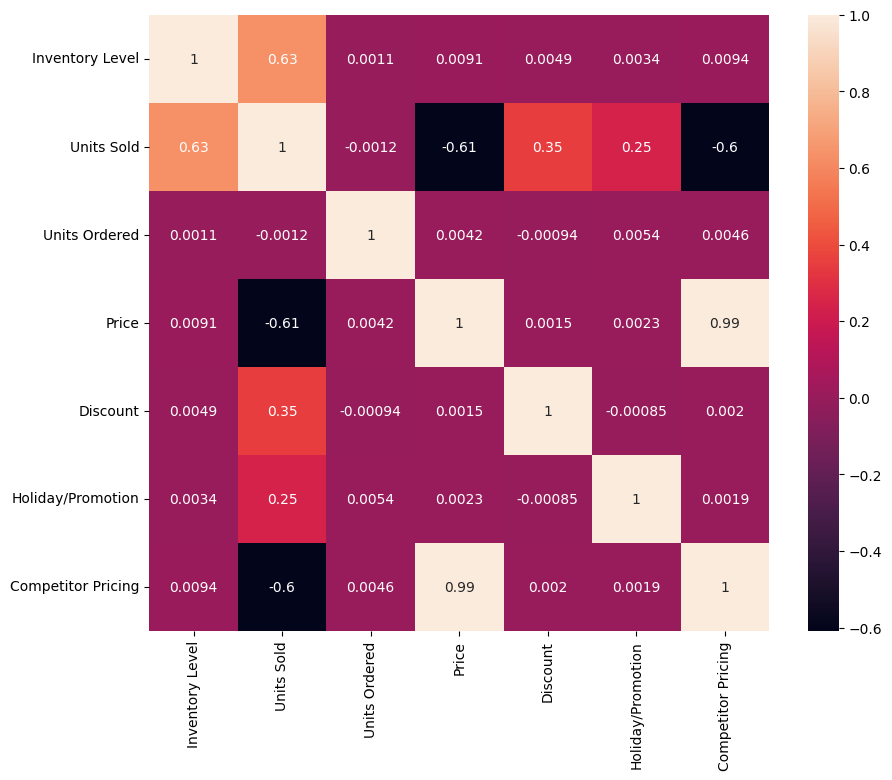

In [13]:
# create new heatmap for the new data
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

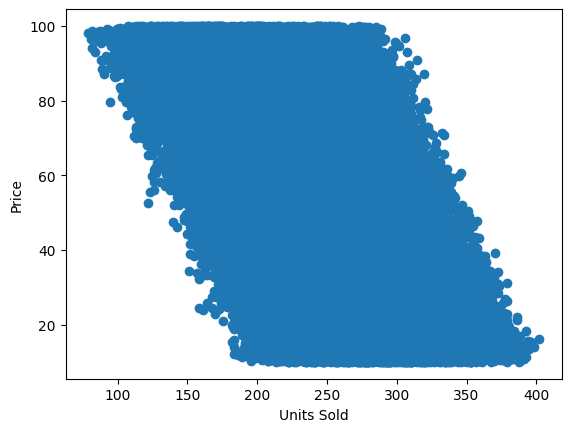

In [14]:
# units sold vs price for new data
plt.scatter(df['Units Sold'], df['Price'])
plt.xlabel('Units Sold')
plt.ylabel('Price')
plt.show()

In [15]:
# change the date column to be compatible with linear regression - split the date to seperate columns
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day Of Week"] = df["Date"].dt.dayofweek
df = df.drop("Date", axis=1)

df.head(5)

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,Day Of Week
0,S001,P0001,Groceries,North,231,272.517142,55,33.50,20,Rainy,0,29.69,Autumn,2022,1,1,5
1,S001,P0002,Toys,South,204,224.005357,66,63.01,20,Sunny,0,66.16,Autumn,2022,1,1,5
2,S001,P0003,Toys,West,102,248.388885,51,27.99,10,Sunny,1,31.32,Summer,2022,1,1,5
3,S001,P0004,Toys,North,469,343.216299,164,32.72,10,Cloudy,1,34.74,Autumn,2022,1,1,5
4,S001,P0005,Electronics,East,166,150.790466,135,73.64,0,Sunny,0,68.95,Summer,2022,1,1,5


In [16]:
from pandas.core.arrays import categorical
from numpy._core import numeric
# start building models for forecasting sales
# linear regression to predict units sold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# state X and y
X = df.drop("Units Sold", axis=1)
y = df["Units Sold"]

# drop store id and product id
X = X.drop(columns=["Store ID","Product ID"])

# seperate numerical columns for scaling
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(exclude=["int64", "float64"]).columns

# use standard scalar
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# encode other columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model = LinearRegression()
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

# check against actual values
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# check rmse
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 100.46039997927132
Root Mean Squared Error: 10.022993563764835


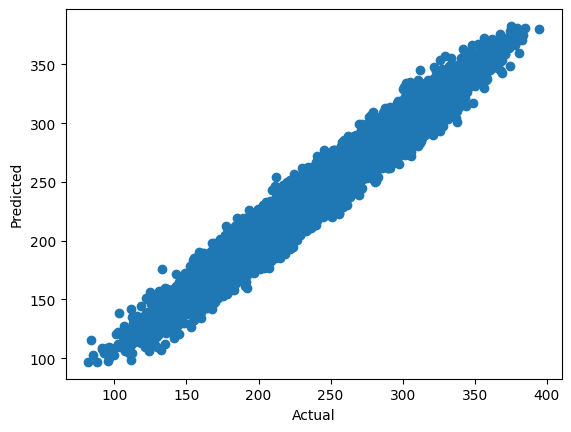

In [17]:
# visualise prediction and actual
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [18]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

# train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

#rmse
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 113.2716773906275
Root Mean Squared Error: 10.642916770821216


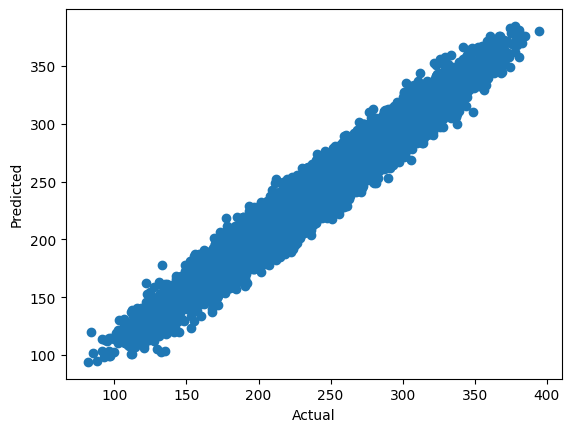

In [19]:
# visualise predictions vs actual
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [20]:
# Tuning hyperparameters
# Random forest with more estimators
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

# rmse
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 112.98222269134698
Root Mean Squared Error: 10.629309605583373


In [21]:
import xgboost as xgb

# train the xgboost model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

# rmse
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 110.12077326432798
Root Mean Squared Error: 10.4938445416505


In [22]:
# cross validation score for all models
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb.XGBRegressor(), X, y, cv=5, scoring="neg_mean_squared_error")
rmse_scores = np.sqrt(-scores)

print(f"XGBoost: {rmse_scores.mean()}")


XGBoost: 10.484690357934362


In [23]:
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="neg_mean_squared_error")
rmse_scores = np.sqrt(-scores)

print(f"Linear Regression: {rmse_scores.mean()}")

Linear Regression: 10.01097575285077


In [24]:
scores = cross_val_score(RandomForestRegressor(n_estimators=50), X, y, cv=5, scoring="neg_mean_squared_error")
rmse_scores = np.sqrt(-scores)

print(f"Random Forest: {rmse_scores.mean()}")

Random Forest: 10.639595631309412


In [25]:
# feature importance for the models
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

importances = model_lr.coef_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("Linear Regression Feature Importance:")
print(feat_imp.head(10))

Linear Regression Feature Importance:
Inventory Level       32.435158
Discount              17.756338
Holiday/Promotion     12.453756
Competitor Pricing     0.465040
Day_3                  0.429118
Day_27                 0.428861
Day_21                 0.378111
Day_2                  0.370154
Category_Furniture     0.209152
Month_6                0.177957
dtype: float64


In [26]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

importances = model_rf.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("Random Forest Feature Importance:")
print(feat_imp.head(10))

Random Forest Feature Importance:
Inventory Level            0.412195
Price                      0.361406
Discount                   0.120489
Holiday/Promotion          0.057582
Competitor Pricing         0.025249
Units Ordered              0.004212
Year_2023                  0.000612
Region_West                0.000504
Seasonality_Summer         0.000498
Weather Condition_Sunny    0.000498
dtype: float64


In [27]:
model_xgb = xgb.XGBRegressor()
model_xgb.fit(X_train, y_train)

importances = model_xgb.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("XGBoost Feature Importance:")
print(feat_imp.head(10))

XGBoost Feature Importance:
Price                 0.301354
Discount              0.248323
Inventory Level       0.230988
Holiday/Promotion     0.154170
Competitor Pricing    0.005479
Day_16                0.001207
Day Of Week_4         0.001161
Day_8                 0.001115
Day_31                0.001107
Day_13                0.001103
dtype: float32


In [28]:
# moving onto stock predictions using the best performing model - linear regression
preds = model_lr.predict(X)

In [29]:
# compare to inventory
df["Predicted Demand"] = preds
df["Stock Gap"] = df["Inventory Level"] - df["Predicted Demand"]

In [30]:
# create rules based on the gap
def stock_status(x):
    if x < -10:
        return "Understock"
    elif x > 20:
        return "Overstock"
    else:
        return "Optimal"

df["Stock Status"] = df["Stock Gap"].apply(stock_status)

In [31]:
# add recommendation actions based on the status of stock
def recommendation(x):
    if x < -10:
        return "Increase stock"
    elif x > 20:
        return "Reduce stock"
    else:
        return "Maintain"

df["Recommendation"] = df["Stock Gap"].apply(recommendation)

In [32]:
# Calculate the lost sales and excess stock
df["Lost Sales"] = df["Stock Gap"].apply(lambda x: abs(x) if x < 0 else 0)
df["Excess Stock"] = df["Stock Gap"].apply(lambda x: abs(x) if x > 0 else 0)

In [33]:
# summarise insights
df["Stock Status"].value_counts()

,count
Stock Status,
Overstock,39532
Understock,27030
Optimal,6538
